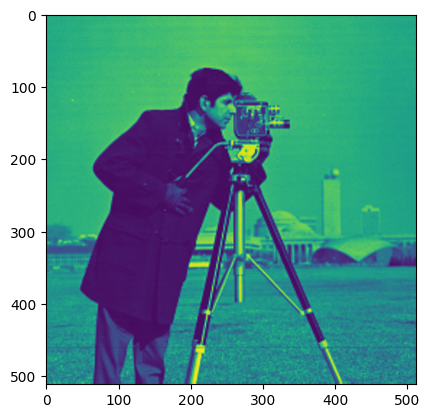

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/drive/MyDrive/AI/cameraman.png")  # Load image
plt.imshow(img)
plt.show()

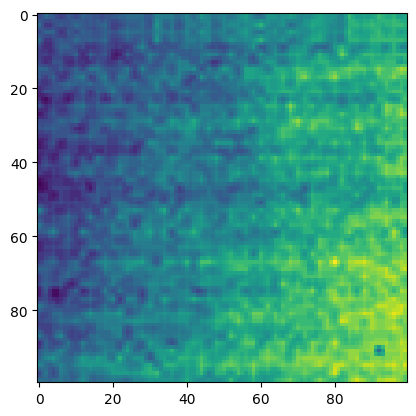

In [24]:
import numpy as np

img_array = np.array(img)  # Convert to NumPy array
top_left = img_array[:100, :100]  # First 100 rows, first 100 cols
plt.imshow(top_left)
plt.show()

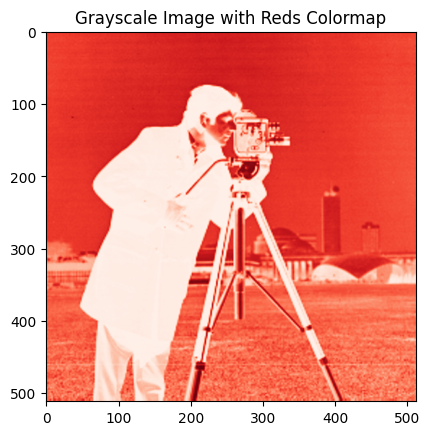

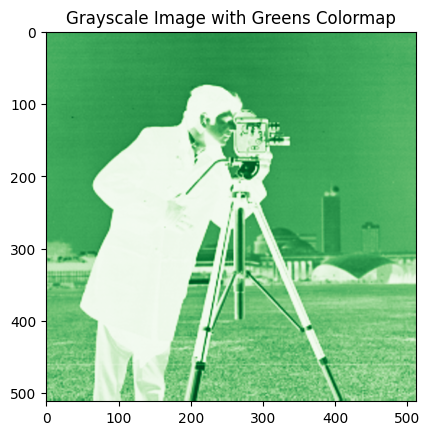

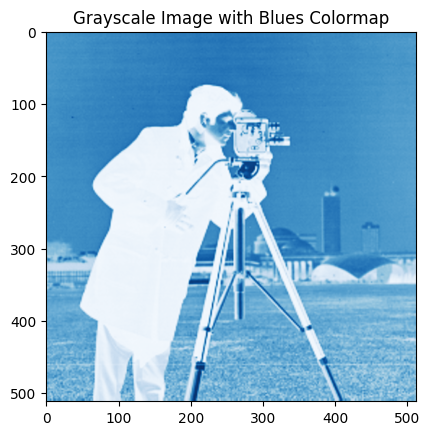

In [25]:
r_channel = img_array  # Grayscale image, so no separate color channels to extract
g_channel = img_array  # Grayscale image
b_channel = img_array  # Grayscale image

plt.imshow(r_channel, cmap="Reds")
plt.title("Grayscale Image with Reds Colormap")
plt.show()

plt.imshow(g_channel, cmap="Greens")
plt.title("Grayscale Image with Greens Colormap")
plt.show()

plt.imshow(b_channel, cmap="Blues")
plt.title("Grayscale Image with Blues Colormap")
plt.show()

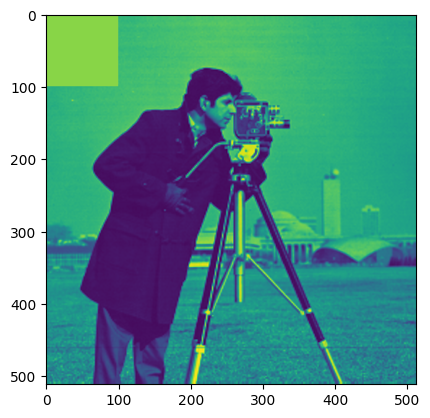

In [26]:
img_array[:100, :100] = 210  # Assign new value
plt.imshow(img_array)
plt.show()

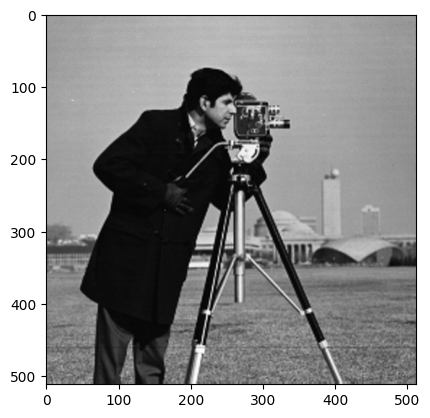

In [27]:
img_gray = Image.open("/content/drive/MyDrive/AI/cameraman.png").convert("L")  # "L" = grayscale
plt.imshow(img_gray, cmap="gray")
plt.show()

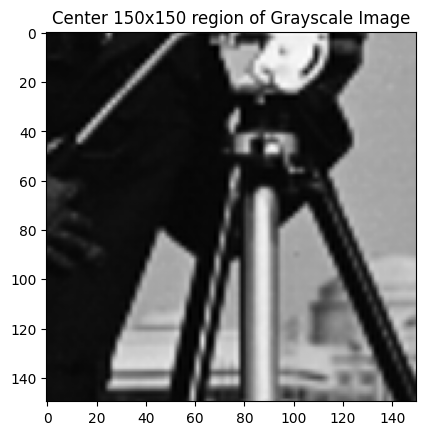

In [28]:
img_gray_array = np.array(img_gray)
h, w = img_gray_array.shape
center = img_gray_array[h//2 - 75 : h//2 + 75, w//2 - 75 : w//2 + 75]
plt.imshow(center, cmap="gray")
plt.title("Center 150x150 region of Grayscale Image")
plt.show()

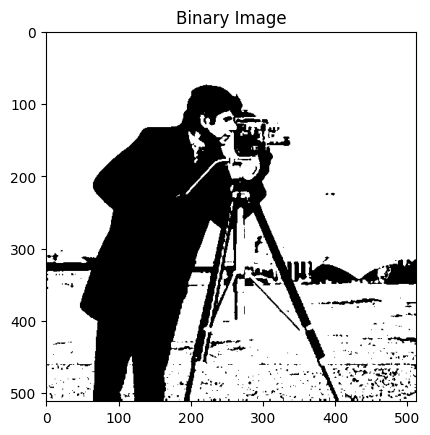

In [29]:
binary = np.where(img_gray_array < 100, 0, 255)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.show()

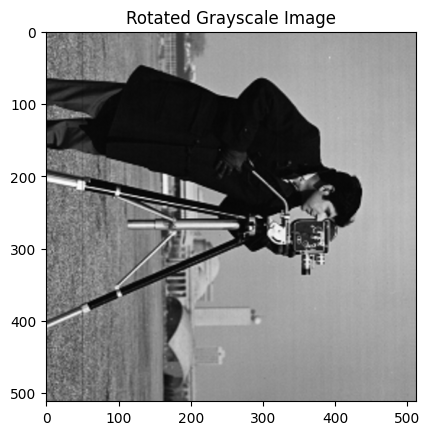

In [31]:
rotated = img_gray.rotate(-90)  # -90 = clockwise
plt.imshow(rotated, cmap="gray")
plt.title("Rotated Grayscale Image")
plt.show()

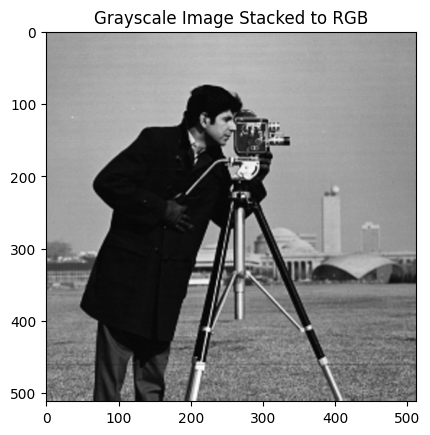

In [32]:
rgb_from_gray = np.stack([img_gray_array]*3, axis=-1)
plt.imshow(rgb_from_gray)
plt.title("Grayscale Image Stacked to RGB")
plt.show()

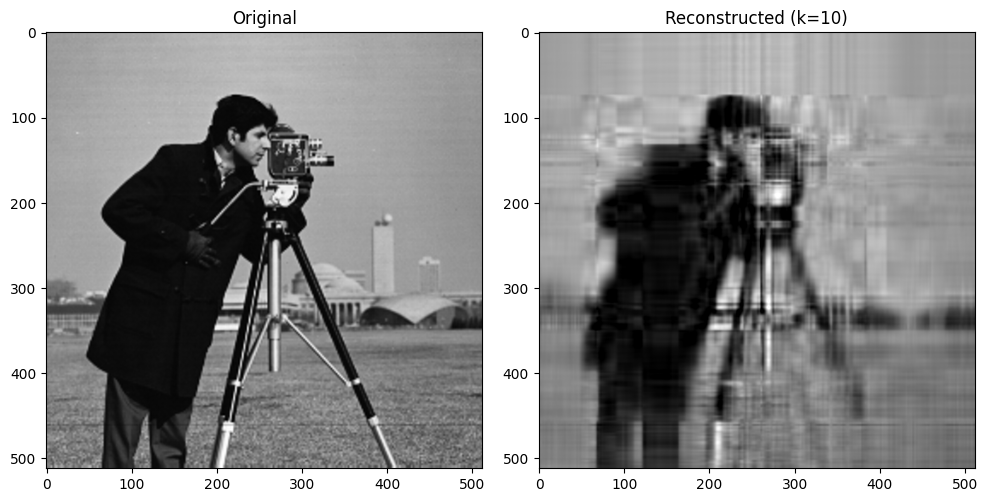

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load and prepare image
img = Image.open("/content/drive/MyDrive/AI/cameraman.png").convert("L")  # grayscale
img_array = np.array(img) / 255.0  # normalize to [0,1]
h, w = img_array.shape

# 2. PCA from scratch
data = img_array
mean = np.mean(data, axis=0)
centered = data - mean
cov_matrix = np.cov(centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 3. Sort and choose k components
k = 10  # try 20, 50, 100
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]
top_eigenvectors = eigenvectors[:, :k]

# 4. Compress and reconstruct
projected = centered @ top_eigenvectors
reconstructed = projected @ top_eigenvectors.T + mean

# 5. Fix value range and display
reconstructed = np.clip(reconstructed, 0, 1)
reconstructed = reconstructed.astype(np.float32)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_array, cmap='gray')
plt.title('Original')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (k={k})')

plt.tight_layout()
plt.show()